# Tutorial 03 · Noise, Integration, and Dataset Generation

This notebook connects the simulator to an ML-friendly workflow.
The main question is:

> **How do shared charge-noise trajectories turn into integrated IQ clusters, and how can those results be saved as a dataset?**

We will define:

- a two-state readout problem
- a reusable library noise model
- a compact dataset through `generate_sensor_iq_dataset(...)`
- a set of integrated IQ views that are useful both for tutorials and for ML inspection


## Noise-To-Dataset Roadmap

Before going into the details, it helps to keep the full pipeline in mind:

1. define the two-state readout problem
2. choose a reusable noise model from the module
3. generate raw I/Q traces for many realisations
4. integrate in time
5. sample integrated IQ points at selected readout times
6. save the result as a dataset

Notebook 3 focuses on how shared noise becomes integrated IQ structure and an ML-ready dataset.


In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == 'tutorials' else Path.cwd()
sys.path.append(str(repo_root / 'src'))

from readout_simulator import QuantumDotSystem, RLC_sensor, generate_sensor_iq_dataset
from readout_simulator.helper_functions import plot_coulomb_peak_minimal
from readout_simulator.noise_models import SpectrumNoise

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 125,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.color': '#cbd5e1',
    'axes.facecolor': '#fcfcfe',
})



## 1. Define the Readout Problem

This is the place to modify the **physics inputs**:

- `Cdd` and `Cds` define the electrostatics
- the `RLC_sensor(...)` block defines the resonator and Coulomb peak
- `charge_states` defines which states become your class labels
- `times`, `integration_times_ns`, and `n_realisations` define the size of the dataset


For this problem, we define a geometry of **2 dots and 1 sensor**.


In [10]:
dot_system = QuantumDotSystem(
    Cdd=np.array([[1.0, -0.22], [-0.22, 1.0]]),
    Cds=np.array([[0.4], [0.2]]),
)

sensor = RLC_sensor(
    {'Lc': 800e-9, 'Cp': 0.5e-12, 'RL': 40, 'Rc': 0.0, 'Z0': 50},
    {'g0': 1/50, 'eps0': 0.45, 'eps_width': 1.0},
)

times = np.arange(0, 1.2e-6, 1e-9)
times_ns = 1e9 * times

charge_states = np.array([
    [1, 0],
    [0, 1],
])
charge_state_labels = ['[1, 0]', '[0, 1]']

n_realisations = 50
integration_times_ns = np.array([20, 60, 120, 250, 500])
integration_indices = np.clip((integration_times_ns - 1).astype(int), 0, len(times) - 1)

simulation_params = {'eps0': 0.0}



[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 0.000e+00 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: None
  Energy noise model: None


## 2. Inspect the Sensor Conductance Peak

Before generating a whole dataset, it is helpful to see whether the chosen charge states actually separate the sensor along the Coulomb peak.
This figure shows:

- the chosen sensor operating point
- the detuning shift between the two charge states
- later, the same shared noise trajectory overlaid on top of the peak



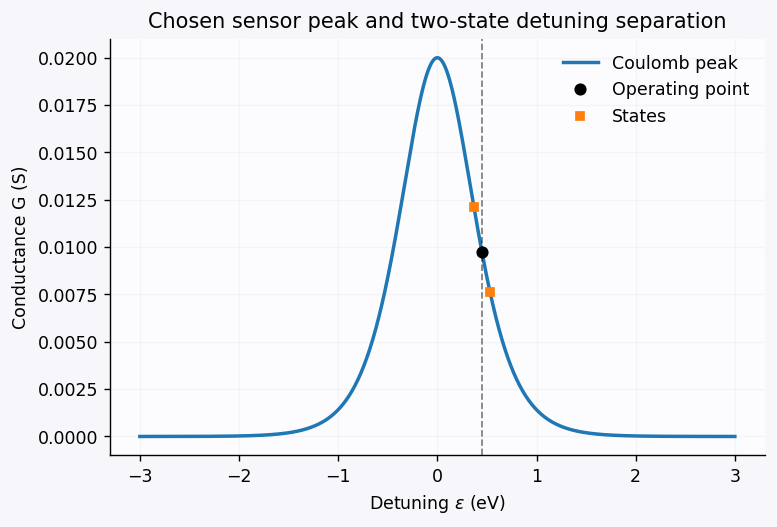

In [11]:
offsets = [
    dot_system.get_energy_offset(state, np.array([0.0]), eps0=0.0)[0]
    for state in charge_states
]
delta_eps = abs(offsets[1] - offsets[0])

fig, ax = plt.subplots(figsize=(6.1, 4.1), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')
sensor_peak_params = {
    'g0': 1 / sensor.R0,
    'eps0': sensor.eps0 / sensor.eps_w,
    'eps_width': sensor.eps_w,
}
plot_coulomb_peak_minimal(sensor_peak_params, delta_eps=delta_eps, ax=ax)
ax.set_title('Chosen sensor peak and two-state detuning separation', fontsize=12)
plt.show()



### What To Notice

- The Coulomb-peak plot is a quick check that the two states actually move the sensor in a distinguishable way.
- The later noise overlay uses the same peak, so it links the abstract dataset back to the sensor physics.
- This is a useful checkpoint before generating many traces.


## 3. Define the Shared Noise Model

The shared noise trajectory is reused across charge states for a given realisation.
That is helpful because it isolates the effect of the charge state itself from the randomness of drawing different noise each time.

Importantly, this notebook **does use the module** for noise generation:

- `SpectrumNoise` from `readout_simulator.noise_models` generates the actual trajectory
- the small local `psd_1f(freq)` function only defines the *shape* of the spectrum used by that module class

This cell is the right place to change:

- the noise model class
- the PSD shape
- the overall RMS amplitude `sigma`


In [17]:
def psd_1f(freq):
    return np.where(freq > 0, 1 / freq, 0.0)

noise_model = SpectrumNoise(psd_func=psd_1f, sigma=0.12)


## 4. Generate a Compact Dataset

The dataset generator returns raw traces, integrated traces, and optionally sampled integrated points.
That means one call can support both tutorial-style plotting and later ML preprocessing.



In [18]:
dataset = generate_sensor_iq_dataset(
    dot_system=dot_system,
    sensors=[sensor],
    charge_states=charge_states,
    times=times,
    simulation_params=simulation_params,
    noise_model=noise_model,
    n_realisations=n_realisations,
    integration_indices=integration_indices,
    use_stationary_initial_state=True,
)

I_raw = dataset['I_raw']
Q_raw = dataset['Q_raw']
I_int = dataset['I_integrated']
Q_int = dataset['Q_integrated']
I_points = dataset['I_points']
Q_points = dataset['Q_points']
shared_noise = dataset['shared_noise']

print('I_raw shape        :', I_raw.shape)
print('I_integrated shape :', I_int.shape)
print('I_points shape     :', I_points.shape)



C:\Users\rouvenkoch\AppData\Local\Temp\ipykernel_17560\2639875102.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.where(freq > 0, 1 / freq, 0.0)


I_raw shape        : (2, 50, 1, 1200)
I_integrated shape : (2, 50, 1, 1200)
I_points shape     : (2, 50, 1, 5)


## 5. Overlay One Noise Trajectory on the Conductance Peak

This view is especially useful for tutorials because it connects abstract noise to the sensor physics directly.
You can see the same `1/f` trajectory wandering along the conductance curve that the sensor uses during the readout.


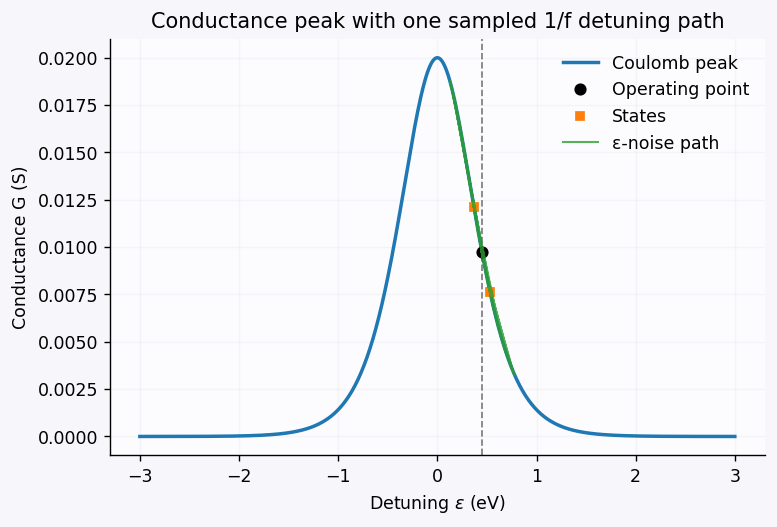

In [20]:
fig, ax = plt.subplots(figsize=(6.1, 4.1), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')
plot_coulomb_peak_minimal(
    sensor_peak_params,
    delta_eps=delta_eps,
    eps_noise=shared_noise[0],
    ax=ax,
)
ax.set_title('Conductance peak with one sampled 1/f detuning path', fontsize=12)
plt.show()


### What To Notice

- The detuning path is easier to interpret once it is drawn directly on the conductance peak.
- This makes it clear that the same time-dependent noise is changing where the operating point sits on the sensor response.
- That physical picture helps explain the broadening seen later in the time traces and IQ clouds.


## 6. Shared Noise and Time-Domain Readout

This figure shows five linked views:

- one shared noise trajectory
- the raw `I` traces for both charge states
- the raw `Q` traces for both charge states
- the corresponding running-average integrated `I` traces
- the corresponding running-average integrated `Q` traces

The dashed vertical lines mark the integration times we later use when sampling IQ points.


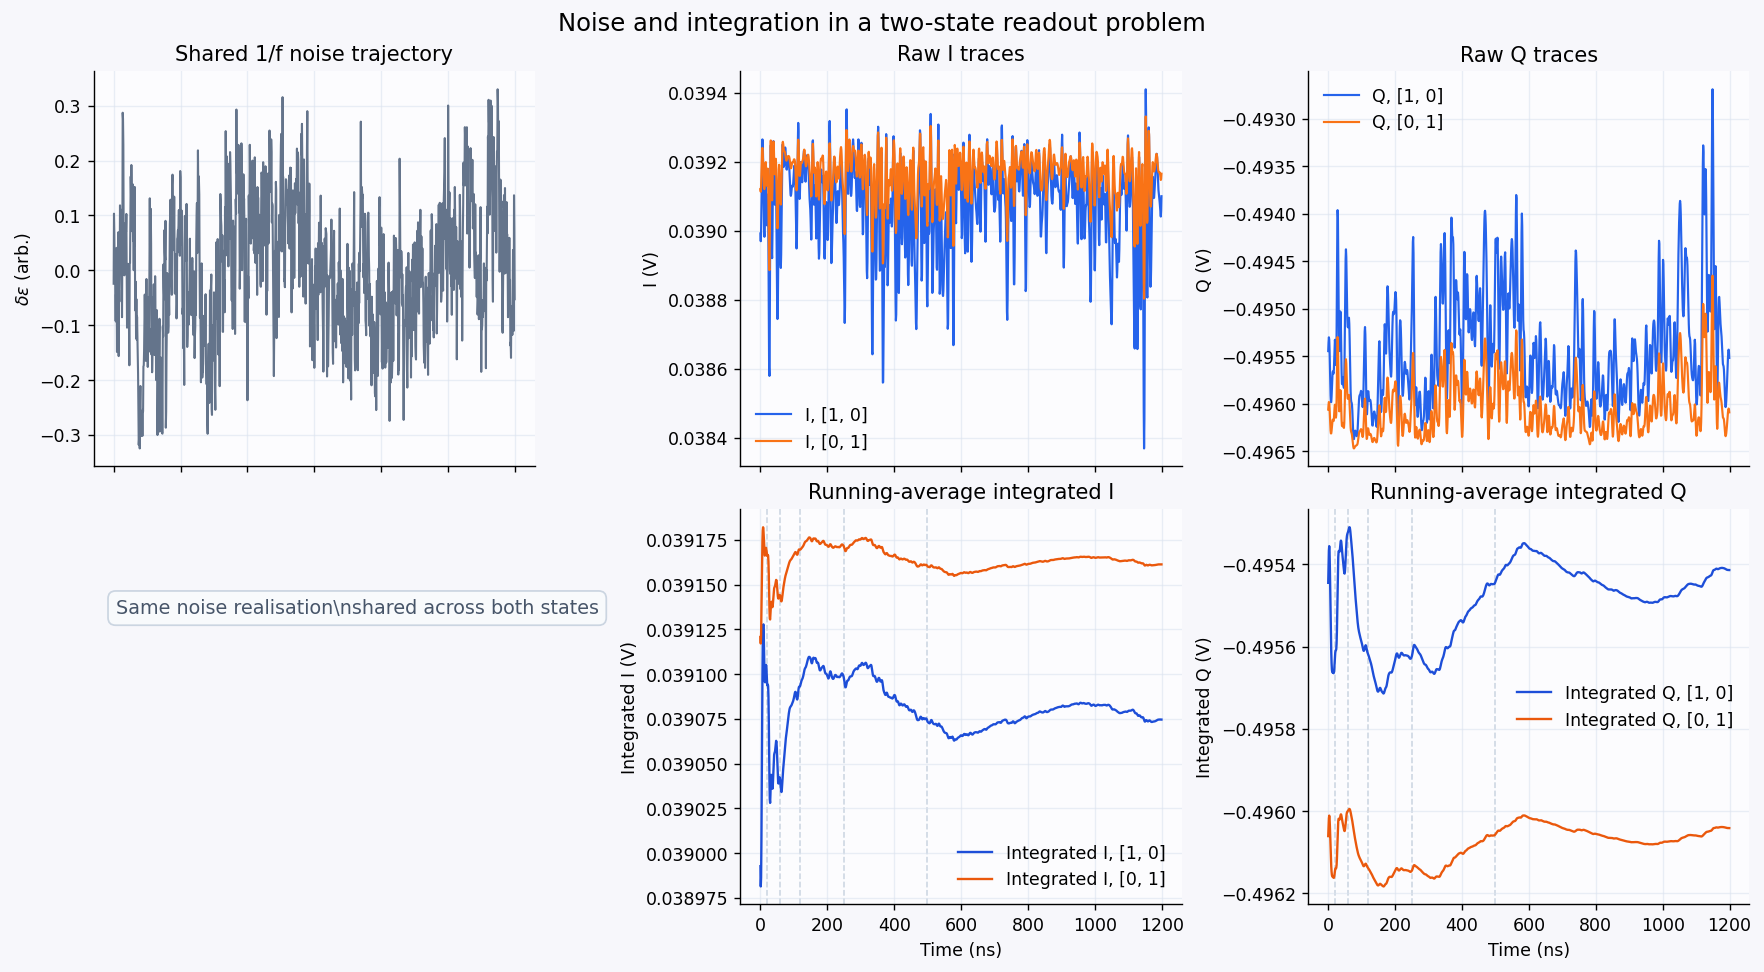

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.4), constrained_layout=True, sharex='col')
fig.patch.set_facecolor('#f7f7fb')

state_colours = ['#2563EB', '#F97316']

axes[0, 0].plot(times_ns, shared_noise[0], color='#64748B', lw=1.2)
axes[0, 0].set_title('Shared 1/f noise trajectory', fontsize=12)
axes[0, 0].set_ylabel('$\\delta \\epsilon$ (arb.)')

axes[0, 1].plot(times_ns, I_raw[0, 0, 0], color=state_colours[0], lw=1.25, label='I, [1, 0]')
axes[0, 1].plot(times_ns, I_raw[1, 0, 0], color=state_colours[1], lw=1.25, label='I, [0, 1]')
axes[0, 1].set_title('Raw I traces', fontsize=12)
axes[0, 1].set_ylabel('I (V)')
axes[0, 1].legend(frameon=False)

axes[0, 2].plot(times_ns, Q_raw[0, 0, 0], color=state_colours[0], lw=1.25, label='Q, [1, 0]')
axes[0, 2].plot(times_ns, Q_raw[1, 0, 0], color=state_colours[1], lw=1.25, label='Q, [0, 1]')
axes[0, 2].set_title('Raw Q traces', fontsize=12)
axes[0, 2].set_ylabel('Q (V)')
axes[0, 2].legend(frameon=False)

axes[1, 0].axis('off')
axes[1, 0].text(
    0.05,
    0.75,
    'Same noise realisation\\nshared across both states',
    fontsize=11,
    color='#475569',
    ha='left',
    va='center',
    transform=axes[1, 0].transAxes,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8FAFC', edgecolor='#CBD5E1')
)

axes[1, 1].plot(times_ns, I_int[0, 0, 0], color='#1D4ED8', lw=1.35, label='Integrated I, [1, 0]')
axes[1, 1].plot(times_ns, I_int[1, 0, 0], color='#EA580C', lw=1.35, label='Integrated I, [0, 1]')
for idx in integration_indices:
    axes[1, 1].axvline(times_ns[idx], color='#CBD5E1', lw=0.9, ls='--', zorder=0)
axes[1, 1].set_title('Running-average integrated I', fontsize=12)
axes[1, 1].set_xlabel('Time (ns)')
axes[1, 1].set_ylabel('Integrated I (V)')
axes[1, 1].legend(frameon=False, loc='best')

axes[1, 2].plot(times_ns, Q_int[0, 0, 0], color='#1D4ED8', lw=1.35, label='Integrated Q, [1, 0]')
axes[1, 2].plot(times_ns, Q_int[1, 0, 0], color='#EA580C', lw=1.35, label='Integrated Q, [0, 1]')
for idx in integration_indices:
    axes[1, 2].axvline(times_ns[idx], color='#CBD5E1', lw=0.9, ls='--', zorder=0)
axes[1, 2].set_title('Running-average integrated Q', fontsize=12)
axes[1, 2].set_xlabel('Time (ns)')
axes[1, 2].set_ylabel('Integrated Q (V)')
axes[1, 2].legend(frameon=False, loc='best')

for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 1], axes[1, 2]]:
    ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)

fig.suptitle('Noise and integration in a two-state readout problem', fontsize=14, y=1.03)
plt.show()


### What To Notice

- The noise trajectory is generated by the module and then reused across both charge states in the dataset generator.
- The raw traces wander visibly, but the running-average integrated traces are much smoother.
- This is the core reason the notebook moves from time traces to sampled integrated IQ points in the next section.


## 7. Integrated IQ Clouds Across Readout Times

We now look at the sampled integrated points.
For a cleaner tutorial figure, the axes are chosen so the clusters look more circular and easier to compare across integration times.

The idea is:

- estimate a robust centre from all sampled points
- use a **single symmetric span** in `I` and `Q`
- keep the same limits across panels so readout-time evolution is visually comparable


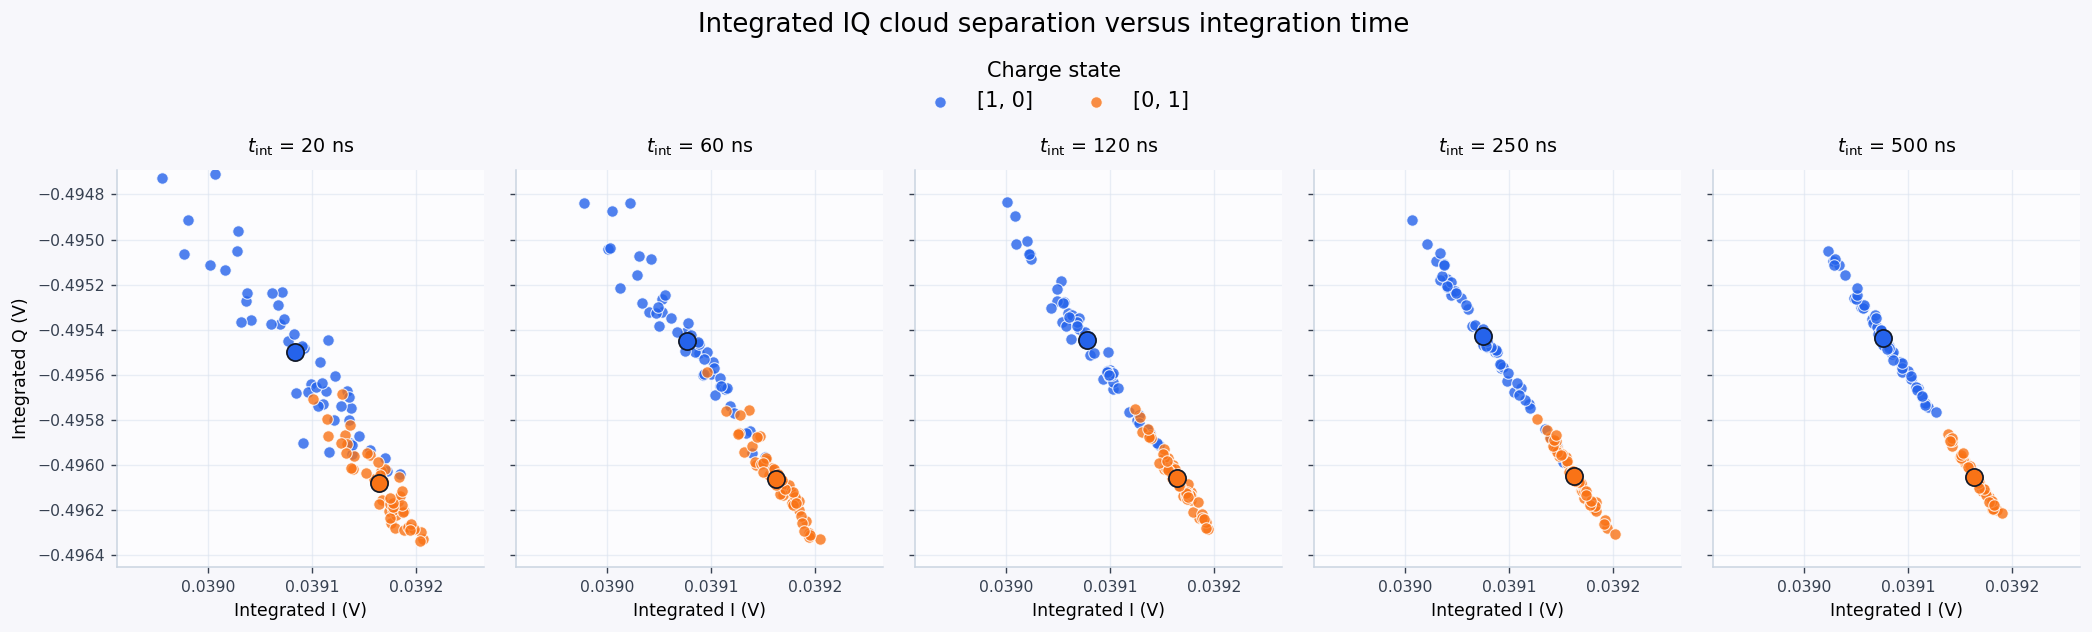

In [34]:
state_colours = ['#2563EB', '#F97316']
sensor_i = I_points[:, :, 0, :]
sensor_q = Q_points[:, :, 0, :]

x_lo, x_hi = np.quantile(sensor_i, [0.01, 0.99])
y_lo, y_hi = np.quantile(sensor_q, [0.01, 0.99])
x_center = 0.5 * (x_lo + x_hi)
y_center = 0.5 * (y_lo + y_hi)
half_span = 0.60 * max(x_hi - x_lo, y_hi - y_lo)
half_span = max(half_span, 1e-9)

fig, axes = plt.subplots(
    1,
    len(integration_times_ns),
    figsize=(3.35 * len(integration_times_ns), 3.95),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
fig.patch.set_facecolor('#f7f7fb')

for col_idx, time_ns in enumerate(integration_times_ns):
    ax = axes[col_idx]
    ax.set_facecolor('#fcfcfe')

    for state_idx, label in enumerate(charge_state_labels):
        x = I_points[state_idx, :, 0, col_idx]
        y = Q_points[state_idx, :, 0, col_idx]

        ax.scatter(
            x,
            y,
            s=44,
            alpha=0.80,
            color=state_colours[state_idx],
            edgecolor='white',
            linewidth=0.65,
            label=label if col_idx == 0 else None,
            zorder=2,
        )
        ax.scatter(
            np.mean(x),
            np.mean(y),
            s=98,
            color=state_colours[state_idx],
            edgecolor='#111827',
            linewidth=1.0,
            zorder=4,
        )

    ax.set_title(f'$t_\\mathrm{{int}}$ = {time_ns} ns', fontsize=11, pad=10)
    ax.set_xlim(x_center - 0.2 * half_span, x_center + 0.2 * half_span)
    ax.set_ylim(y_center - half_span, y_center + half_span)
    # ax.set_aspect('equal', adjustable='box')
    ax.grid(True, color='#dbe3ef', alpha=0.58, linewidth=0.8)
    ax.tick_params(labelsize=9, colors='#374151')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)

axes[0].set_ylabel('Integrated Q (V)', fontsize=10)
for ax in axes:
    ax.set_xlabel('Integrated I (V)', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=False,
    title='Charge state',
    fontsize=12,
    title_fontsize=12,
)
fig.suptitle('Integrated IQ cloud separation versus integration time', fontsize=15, y=1.24)
plt.show()



### What To Notice

- Early integration times give broader and less stable IQ separation
- Longer integration times separates the sampled points into tighter clusters
- This is the visual starting point for choosing a useful readout time
